In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [85]:
df=pd.read_csv("C:\\Users\\asus\\OneDrive\\Desktop\\Crop Recommendation dataset.csv")

In [86]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# EDA

In [87]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [89]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [90]:
df.duplicated().sum()

np.int64(0)

In [91]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [92]:
df['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [93]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

# histogram

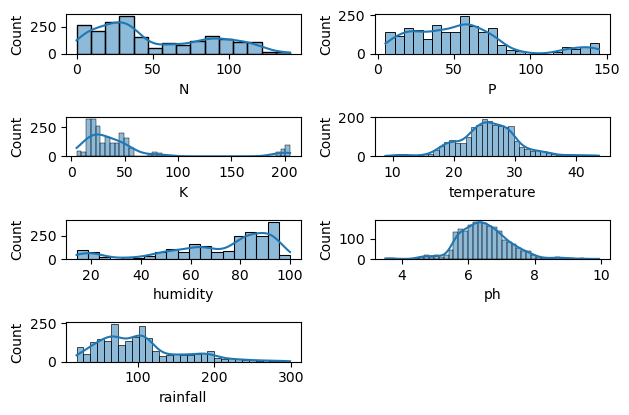

In [94]:
def plotting(var,num):
    plt.subplot(5,2,num)
    sns.histplot(df[var],kde=True)
plotting('N',1)   
plotting('P',2) 
plotting('K',3) 
plotting('temperature',4)
plotting('humidity',5)
plotting('ph',6)
plotting('rainfall',7)

plt.tight_layout()

In [95]:
df.rename(columns={'label':'crop'},inplace=True)

In [96]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# box plot (check outliears)

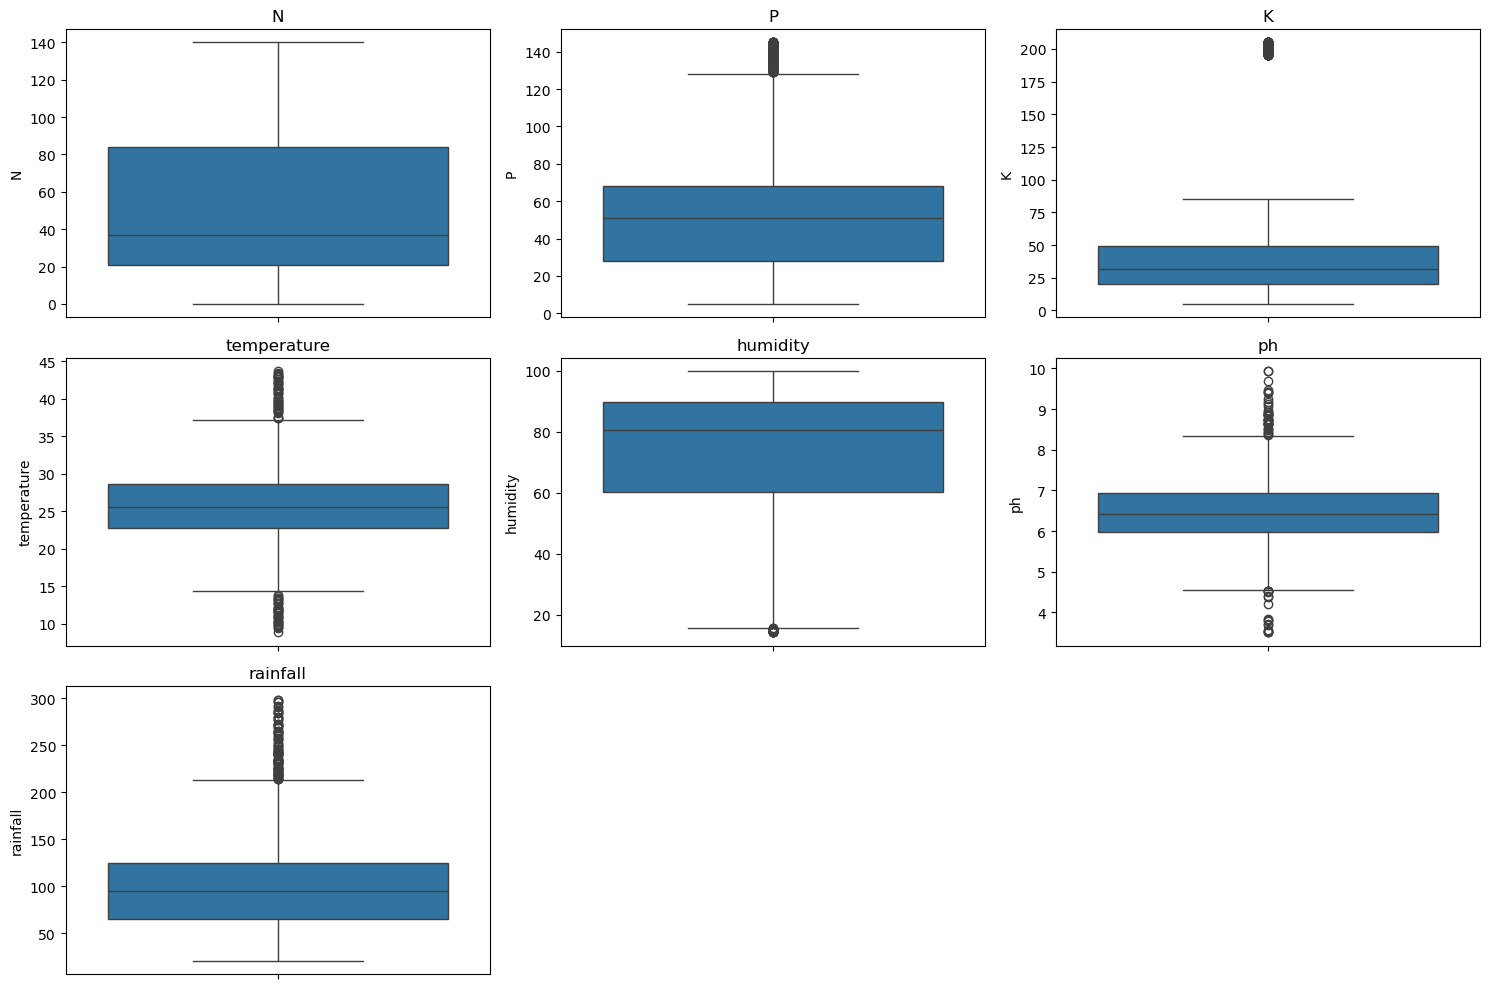

In [97]:
plt.figure(figsize=(15,10))
for i,col in enumerate(df.columns[:-1],1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# correlation heatmap

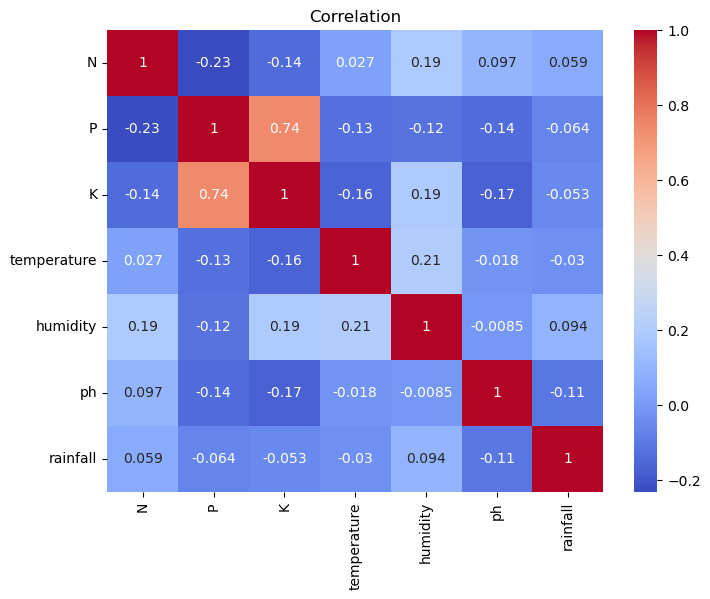

In [98]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation")
plt.show()

# check crop distribulion

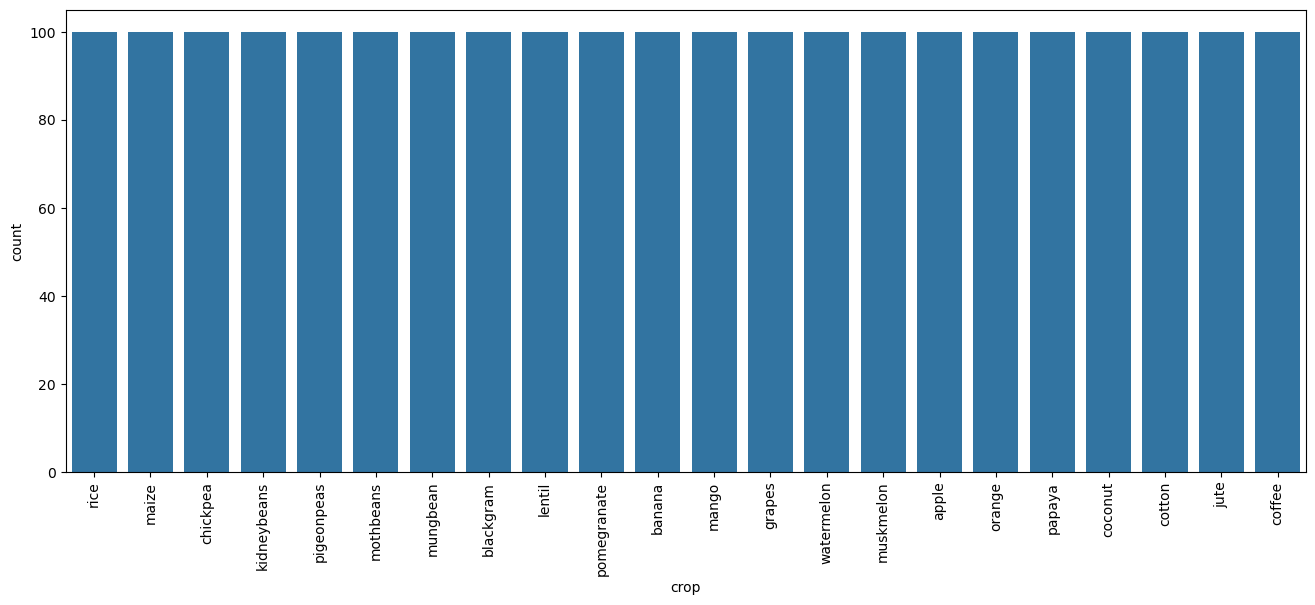

In [99]:
plt.figure(figsize=(16,6))
sns.countplot(x='crop',data=df,order=df['crop'].value_counts().index)
plt.xticks(rotation=90)
plt.xlabel("crop")
plt.ylabel("count")
plt.show()

In [100]:
x=df.drop('crop',axis=1)
y=df['crop']

# label encoding

In [101]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
y=le.fit_transform(y)

to the check

In [102]:
crop_mapping=dict(zip(le.classes_,le.transform(le.classes_)))
crop_mapping

{'apple': np.int64(0),
 'banana': np.int64(1),
 'blackgram': np.int64(2),
 'chickpea': np.int64(3),
 'coconut': np.int64(4),
 'coffee': np.int64(5),
 'cotton': np.int64(6),
 'grapes': np.int64(7),
 'jute': np.int64(8),
 'kidneybeans': np.int64(9),
 'lentil': np.int64(10),
 'maize': np.int64(11),
 'mango': np.int64(12),
 'mothbeans': np.int64(13),
 'mungbean': np.int64(14),
 'muskmelon': np.int64(15),
 'orange': np.int64(16),
 'papaya': np.int64(17),
 'pigeonpeas': np.int64(18),
 'pomegranate': np.int64(19),
 'rice': np.int64(20),
 'watermelon': np.int64(21)}

# train test split

In [103]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [104]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [105]:
from sklearn.metrics import accuracy_score, f1_score ,classification_report,confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [106]:
models={
    "logistic Regression":LogisticRegression(max_iter=1000),
    "KNN":KNeighborsClassifier(),
    "Naive Byeas":GaussianNB(),
    "Decision tree":DecisionTreeClassifier(),
    "SVM":SVC()
}

In [107]:
results=[]

In [108]:
results = []

for name,model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred,average='weighted')

    results.append({
        'model': name,
        'accuracy': round(acc, 4),
        'f1 score': round(f1, 4)
    })

In [109]:
results

[{'model': 'logistic Regression', 'accuracy': 0.9727, 'f1 score': 0.9725},
 {'model': 'KNN', 'accuracy': 0.9795, 'f1 score': 0.9793},
 {'model': 'Naive Byeas', 'accuracy': 0.9955, 'f1 score': 0.9954},
 {'model': 'Decision tree', 'accuracy': 0.9795, 'f1 score': 0.9794},
 {'model': 'SVM', 'accuracy': 0.9841, 'f1 score': 0.984}]

In [110]:
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [111]:
y_pred

array([16,  1,  6, 11, 16,  3, 20,  2,  1, 16, 21, 19, 21, 11,  2,  7,  7,
       12, 12,  0,  2,  0, 13,  9,  0,  8, 13, 21, 20,  5, 12,  8,  1,  5,
        8,  2,  7,  7, 13,  8,  4, 17, 12,  6, 10,  8,  6, 10,  3, 14, 17,
       19, 18, 21, 12, 13, 17, 17,  5, 10, 10, 13,  5,  1, 17, 20, 16,  4,
       11, 19,  1, 15, 21, 10,  1,  4,  2, 14, 14, 12,  5, 21, 15,  9, 12,
       19, 16,  6,  4, 17, 13, 14, 13,  6,  8,  7,  6,  3,  8, 21, 15, 19,
       16, 18, 18,  7,  9, 10, 20, 20,  0, 14, 14,  7, 20, 15,  2, 10,  1,
       16, 16,  3, 11, 12, 11, 10,  1, 19,  4, 14,  6,  3,  8, 14,  2, 11,
        0,  3, 20, 11,  6,  8, 19, 12,  8, 17,  1, 16, 18, 10, 11,  3,  6,
       21, 10,  6, 18, 15,  0, 14, 11,  3, 11, 11,  9,  5, 16, 11,  7, 19,
        0,  4, 15,  7,  6, 10, 18,  3, 11, 13,  0, 15,  6, 21, 15, 21, 16,
       21,  5,  9,  0,  3, 13,  5, 15,  5,  0,  7,  8, 17,  4,  7, 21, 14,
       19, 18, 14,  2, 17, 15,  3,  0, 11,  3,  1, 19, 19,  6, 16,  8,  6,
        6, 11,  7, 14, 10

In [112]:
y_test

array([16,  1,  6, 11, 16,  3, 20,  2,  1, 16, 21, 19, 21, 11, 13,  7,  7,
       12, 12,  0,  2,  0, 13,  9,  0,  8, 13, 21, 20,  5, 12,  8,  1,  5,
        8,  2,  7,  7,  2,  8,  4, 17, 12, 11, 10,  8,  6, 10,  3, 14, 17,
       19, 18, 21, 12,  2, 17, 17,  5, 10, 10, 13,  5,  1, 17, 20, 16,  4,
        2, 19,  1, 15, 21, 10,  1,  4, 13, 14, 14, 12,  5, 21, 15,  9, 12,
       19, 16,  6,  4, 17, 13, 14, 13,  6,  8,  7,  6,  3,  8, 21, 15, 19,
       16, 18, 18,  7,  9, 10, 20, 20,  0, 14, 14,  7, 20, 15,  2, 10,  1,
       16, 16,  3, 11, 12, 11, 10,  1, 19,  4, 14,  6,  3,  8, 14, 13, 11,
        0,  3, 20, 11,  6,  8, 19, 12, 20, 17,  1, 16, 18, 10, 11,  3,  6,
       21, 13, 11, 18, 15,  0, 14,  2,  3, 11, 11,  9,  5, 16, 11,  7, 19,
        0,  4, 15,  7,  6, 10, 18,  3,  2, 13,  0, 15,  6, 21, 15, 21, 16,
       21,  5,  9,  0,  3,  2,  5, 15,  5,  0,  7,  8, 17,  4,  7, 21, 14,
       19, 18, 14, 10, 17, 15,  3,  0, 11,  3,  1, 19, 19, 11, 16,  8,  6,
        6, 11,  7, 14, 10

In [113]:
print("accuract_score",accuracy_score(y_test,y_pred))

accuract_score 0.9431818181818182


In [114]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       0.68      0.65      0.67        20
           3       1.00      1.00      1.00        20
           4       1.00      0.95      0.97        20
           5       1.00      1.00      1.00        20
           6       0.80      1.00      0.89        20
           7       1.00      1.00      1.00        20
           8       0.87      1.00      0.93        20
           9       1.00      1.00      1.00        20
          10       0.89      0.85      0.87        20
          11       0.83      0.75      0.79        20
          12       1.00      1.00      1.00        20
          13       0.75      0.75      0.75        20
          14       1.00      0.95      0.97        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    

# new prediction 

In [115]:
sample=[[5,62,23,27.811,66.205,4.7,150.060]]
sample=scaler.transform(sample)
prediction=model.predict(sample)
print("Recommended Crop",le.inverse_transform(prediction))

Recommended Crop ['pigeonpeas']


In [116]:
sample1 = [[90,42,43,20.8,82,6.5,202]]
sample1 = scaler.transform(sample1)
print(le.inverse_transform(model.predict(sample1)))

sample2 = [[78,42,42,20.13,81.61,7.62,262]]
sample2 = scaler.transform(sample2)
print(le.inverse_transform(model.predict(sample2)))

['rice']
['rice']


In [117]:
import joblib
joblib.dump(model,"crop_model.pkl")
joblib.dump(scaler,"scaler.pkl")
joblib.dump(le,"label_encoder.pkl")

print("Model saved succesfully!")

Model saved succesfully!


In [118]:
rice_data = df[df["crop"] == "rice"].head(5)
print(rice_data)


    N   P   K  temperature   humidity        ph    rainfall  crop
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [119]:
sample = rice_data.iloc[4][["N","P","K","temperature","humidity","ph","rainfall"]].values.reshape(1,-1)

sample = scaler.transform(sample)

pred = model.predict(sample)

print("Actual :", rice_data.iloc[0]["crop"])
print("Predicted :", le.inverse_transform(pred))

Actual : rice
Predicted : ['rice']


In [120]:
from sklearn.metrics import accuracy_score

train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))

Train Accuracy: 0.9755681818181818
Test Accuracy : 0.9431818181818182
